# SALEO Demo

Import

In [1]:
from __future__ import annotations

import os

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pyiqa
import torch

import saleo
from mon import albumentations as A, image as I, Path, cv

/home/longpham/miniconda3/envs/mon/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/longpham/miniconda3/envs/mon/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


[15:02:21] `mon` loaded in: 0.6913 seconds.                                                          ]8;id=907991;file:///home/longpham/10_workspace/11_code/mon/libs/mon/src/mon/__init__.py\__init__.py]8;;\:]8;id=833042;file:///home/longpham/10_workspace/11_code/mon/libs/mon/src/mon/__init__.py#22\22]8;;\

Setup environment

In [2]:
current_dir = Path(os.getcwd())
root_dir    = current_dir.parents[0]
data_dir    = current_dir / "demo"
output_dir  = current_dir / "demo"

device      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
results     = {}

# Debug
print(f"Device: {device}")

Device: cuda


Resolve I/O

In [3]:
# image_name = "993_UHD_LL"
image_name = "1513_UHD_LL"

image_file = (data_dir / image_name / f"{image_name}").image_file()
depth_file = (data_dir / image_name / f"{image_name}_depth").image_file()
ref_file   = (data_dir / image_name / f"{image_name}_ref").image_file()

# Load data
image = cv2.imread(str(image_file))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

depth = cv2.imread(str(depth_file), cv2.IMREAD_GRAYSCALE)
if depth.ndim == 2:
    depth = np.expand_dims(depth, axis=-1)

ref   = cv2.imread(str(ref_file))
ref   = cv2.cvtColor(ref, cv2.COLOR_BGR2RGB)

# Debug
print(f"Image shape: {image.shape}")
print(f"Depth shape: {depth.shape}")
print(f"Ref shape  : {ref.shape}")
assert image.shape[0:2] == depth.shape[0:2], "'image' and 'depth' must have the same resolution."

Image shape: (2160, 3840, 3)
Depth shape: (2160, 3840, 1)
Ref shape  : (2160, 3840, 3)


Pre-process

In [4]:
# Normalize and convert to torch.Tensor
transform   = A.Compose([
    A.NormalizeWithMask(normalization="min_max"),
    A.ToTensorV2(transpose_mask=True),
], additional_targets={"ref": "image"})
transformed = transform(image=image, mask=depth, ref=ref)

image_t = transformed["image"]
depth_t = transformed["mask"]
ref_t   = transformed["ref"]

image_t = image_t.unsqueeze(0)
depth_t = depth_t.unsqueeze(0)
ref_t   = ref_t.unsqueeze(0)

# Debug
print(f"Image shape: {image_t.shape}. Is normalized: {I.is_normalized(image_t)}.")
print(f"Depth shape: {depth_t.shape}. Is normalized: {I.is_normalized(depth_t)}.")
print(f"Ref shape  : {ref_t.shape}. Is normalized: {I.is_normalized(ref_t)}.")

Image shape: torch.Size([1, 3, 2160, 3840]). Is normalized: True.
Depth shape: torch.Size([1, 1, 2160, 3840]). Is normalized: True.
Ref shape  : torch.Size([1, 3, 2160, 3840]). Is normalized: True.


Process

In [5]:
def test_baseline(
    epochs    : int   = 100,
    E         : float = 0.1,
    save_debug: bool  = True,
    verbose   : bool  = False,
):
    global image_t, depth_t, ref_t, results, device

    colie    =    cv.colie(device=device, verbose=verbose)
    colie_pp = cv.colie_pp(device=device, verbose=verbose)

    results["colie"]   =    colie(image=image_t, epochs=epochs, E=E, save_debug=save_debug)
    results["colie++"] = colie_pp(image=image_t, epochs=epochs, E=E, save_debug=save_debug)

In [6]:
def test_arch(
    epochs     : int   = 100,
    batch_size : int   = 16,
    E          : float = 0.1,
    save_debug : bool  = True,
    verbose    : bool  = False,
):
    global image_t, depth_t, ref_t, results, device

    saleo_siren   =   saleo.saleo_siren(device=device, verbose=verbose)
    saleo_ffsiren = saleo.saleo_ffsiren(device=device, verbose=verbose)

    results["siren"]   =   saleo_siren(image_t, depth_t, epochs, batch_size, E, save_debug)
    results["ffsiren"] = saleo_ffsiren(image_t, depth_t, epochs, batch_size, E, save_debug)

In [7]:
test_baseline()
test_arch()

Measure metrics

In [8]:
def measure_metrics():
    global ref_t, results, device

    # Create metric with default setting
    psnr_metric  = pyiqa.create_metric("psnr",  device=device)
    ssim_metric  = pyiqa.create_metric("ssim",  device=device)
    lpips_metric = pyiqa.create_metric("lpips", device=device)

    # Concatenate results for visualization
    titles = ["image"]
    images = [ image ]
    for k1, v1 in results.items():
        titles.append(k1)
        images.append(v1["enhanced"])

    # Measure metrics
    ref_ = ref_t.to(device)
    for i in range(1, len(images)):
        img_ = images[i].to(device)

        psnr_value  = psnr_metric(img_,  ref_).item()
        ssim_value  = ssim_metric(img_,  ref_).item()
        lpips_value = lpips_metric(img_, ref_).item()

        print(f"{titles[i]:10s} | PSNR: {psnr_value:6.2f} | SSIM: {ssim_value:6.4f} | LPIPS: {lpips_value:6.4f}")


measure_metrics()

Loading pretrained model LPIPS from /home/longpham/.cache/torch/hub/checkpoints/LPIPS_v0.1_alex-df73285e.pth
colie      | PSNR:  13.02 | SSIM: 0.4511 | LPIPS: 0.8152
colie++    | PSNR:  13.05 | SSIM: 0.6535 | LPIPS: 0.7238
siren      | PSNR:  12.62 | SSIM: 0.6699 | LPIPS: 0.6748
ffsiren    | PSNR:  14.44 | SSIM: 0.6994 | LPIPS: 0.6909


Post-process

In [9]:
def postprocess():
    global results

    # Convert outputs to numpy arrays
    for k1, v1 in results.items():
        for k2, v2 in v1.items():
            results[k1][k2] = I.to_array(v2)


postprocess()

Visualize

In [10]:
# Setup matplotlib
plt.rcParams["figure.autolayout"] = True

In [11]:
def compare_results(key: str = "enhanced"):
    global results

    # Concatenate results for visualization
    titles = ["image", "depth", "ref"]
    images = [ image,   depth,  ref  ]
    for k1, v1 in results.items():
        titles.append(k1)
        images.append(v1[key])

    # Create a grid of images
    fig, axes = plt.subplots(1, len(images), figsize=(15, 5))
    for i, ax in enumerate(axes):
        ax.imshow(images[i])
        ax.set_title(titles[i])
        ax.axis("off")

    # Adjust the layout and show the plot
    plt.tight_layout()  # Adjust layout to prevent title overlap
    plt.show()

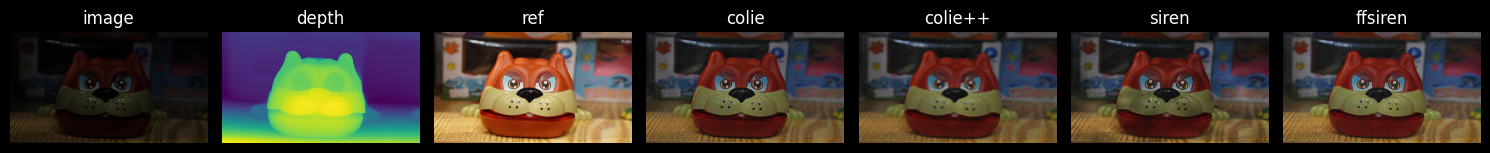

In [12]:
compare_results(key="enhanced")

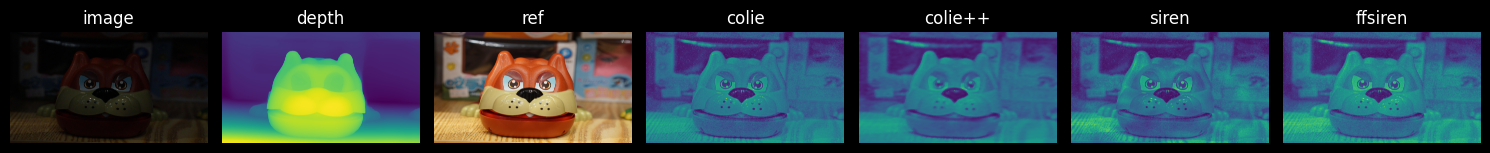

In [13]:
compare_results(key="image_i")

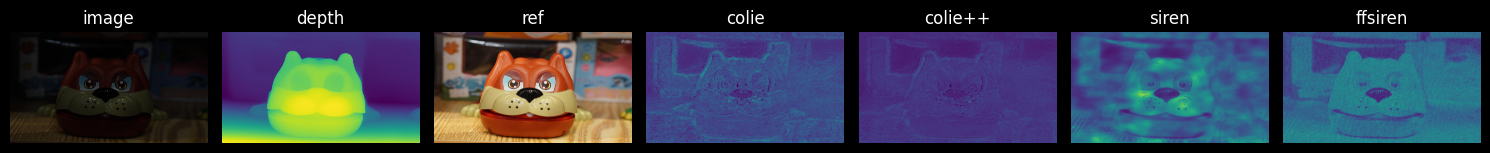

In [14]:
compare_results(key="image_i_res")

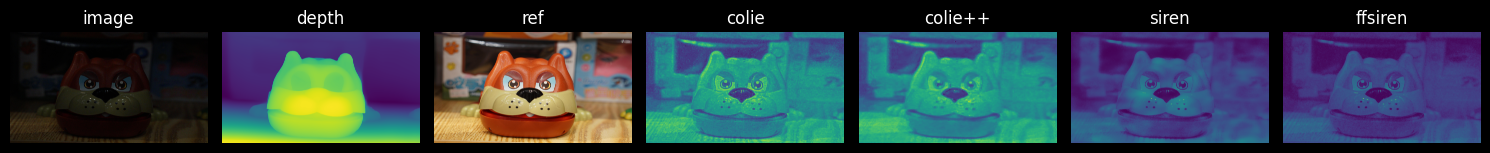

In [15]:
compare_results(key="image_i_fixed")

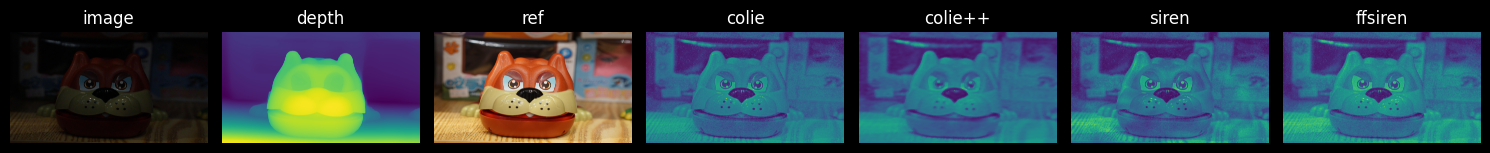

In [16]:
compare_results(key="image_r")

Save

In [17]:
for k1, v1 in results.items():
    for k2, v2 in v1.items():
        output_file = output_dir / f"{image_name}_debug" / f"{image_name}_{k1}_{k2}.jpg"
        I.write(v2, output_file)